# **데이터와 파이썬 패키지 불러오기**

In [7]:
import numpy as np
from scipy.stats import norm

함수 및 매개변수 정의

In [8]:
# 매개변수 정의
true_alpha = 0.1
true_beta = 0.1
true_sigma0 = 0.2

# 블랙-숄즈 옵션 가격책정 모델의 이자율
risk_free_rate = 0.05

콜옵션의 변동성과 가격책정 함수

In [9]:
def option_vol_from_surface(moneyness, time_to_maturity):
    return true_sigma0 + true_alpha * time_to_maturity + true_beta * np.square(moneyness - 1)
def call_option_price(moneyness, time_to_maturity, option_vol):
    d1 = (np.log(1/moneyness)+(risk_free_rate+np.square(option_vol))*time_to_maturity)/(option_vol * np.sqrt(time_to_maturity))
    d2 = (np.log(1/moneyness)+(risk_free_rate-np.square(option_vol))*time_to_maturity)/(option_vol * np.sqrt(time_to_maturity))
    N_d1 = norm.cdf(d1)
    N_d2 = norm.cdf(d2)
    return N_d1 - moneyness * np.exp(-risk_free_rate * time_to_maturity) * N_d2

데이터 생성

In [10]:
N = 10000
Ks = 1 + 0.25 * np.random.randn(N)
Ts = np.random.random(N)
Sigmas = np.array([option_vol_from_surface(k, t) for k, t in zip(Ks, Ts)])
Ps = np.array([call_option_price(k, t, sig) for k, t, sig in zip(Ks, Ts, Sigmas)])

/var/folders/8p/g5q_r1c51x7_mgkd5kmh4s3m0000gn/T/ipykernel_53714/604531170.py:4: RuntimeWarning: invalid value encountered in log
  d1 = (np.log(1/moneyness)+(risk_free_rate+np.square(option_vol))*time_to_maturity)/(option_vol * np.sqrt(time_to_maturity))
/var/folders/8p/g5q_r1c51x7_mgkd5kmh4s3m0000gn/T/ipykernel_53714/604531170.py:5: RuntimeWarning: invalid value encountered in log
  d2 = (np.log(1/moneyness)+(risk_free_rate-np.square(option_vol))*time_to_maturity)/(option_vol * np.sqrt(time_to_maturity))


In [12]:
Y = Ps
X = np.concatenate([Ks.reshape(-1, 1), Ts.reshape(-1, 1), Sigmas.reshape(-1, 1)], axis = 1)
dataset = pd.DataFrame(np.concatenate([Y.reshape(-1, 1), X], axis = 1), columns = ['Price', 'Moneyness', 'Time', 'Vol'])

# **EDA**

기술 통계

In [13]:
dataset.head()

,Price,Moneyness,Time,Vol
0,0.303143,0.800983,0.822742,0.286235
1,0.261324,0.742234,0.096071,0.216251
2,0.248631,0.790925,0.450551,0.249426
3,0.120468,0.981986,0.324335,0.232466
4,0.305896,0.787488,0.797577,0.284274


데이터 시각화

<Figure size 1500x1500 with 0 Axes>

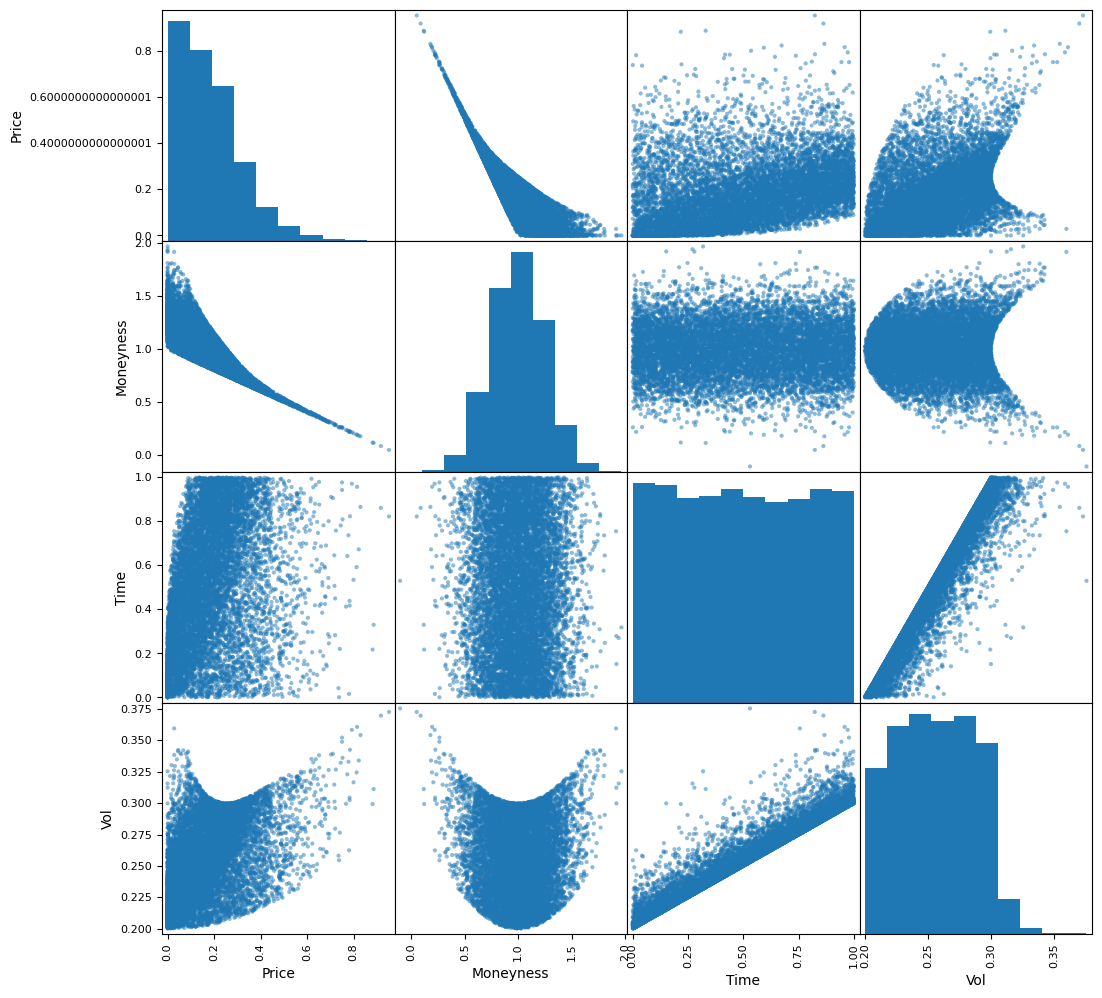

In [14]:
pyplot.figure(figsize=(15, 15))
scatter_matrix(dataset, figsize=(12, 12))
pyplot.show()

# **데이터 준비 및 분석**

단변량 특성 선택

In [17]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_regression

# 1. 데이터 준비 (X는 (N, 3) 형태, Y는 (N,) 형태라고 가정)
# X = np.column_stack([Ks, Ts, Sigmas])
# Y = Ps

# 2. NaN 및 무한대(inf) 제거 (매우 중요!)
# 계산 과정에서 분모가 0이 되거나 log(0)이 발생해 NaN이 생길 수 있습니다.
mask = ~np.isnan(Y) & ~np.isinf(Y)
X_clean = X[mask]
Y_clean = Y[mask]

# 3. Feature Selection 실행
bestfeatures = SelectKBest(k='all', score_func=f_regression)
fit = bestfeatures.fit(X_clean, Y_clean)

# 4. 결과 정리
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(['Moneyness', 'Time', 'Vol'])

# 데이터프레임 연결 및 컬럼명 지정
featureScores = pd.concat([dfcolumns, dfscores], axis=1)
featureScores.columns = ['Specs', 'Score']

# 결과 출력 (상위 10개, 여기서는 3개뿐이지만 nlargest는 그대로 사용 가능)
result = featureScores.nlargest(10, 'Score').set_index('Specs')
print(result)

                  Score
Specs                  
Moneyness  30345.844030
Vol         2475.430906
Time        1556.917979


# **5. 모델 평가**

훈련 - 테스트 분할 및 평가 메트릭

In [18]:
validation_size = 0.2
train_size = int(len(X) * (1 - validation_size))
X_train, X_test = X[0:train_size], X[train_size:len(X)]
Y_train, Y_test = Y[0:train_size], Y[train_size:len(X)]

In [19]:
num_folds = 10
seed = 7
scoring = 'neg_mean_squared_error'

모델 및 알고리즘 비교

In [20]:
models = []
models.append(('LR', LinearRegression()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVR', SVR()))
models.append(('MLP', MLPRegressor()))

부스팅과 배깅 방법

In [21]:
# 부스팅 방법
models.append(('ABR', AdaBoostRegressor()))
models.append(('GBR', GradientBoostingRegressor()))

# 배깅 방법
models.append(('RFR', RandomForestRegressor()))
models.append(('ETR', ExtraTreesRegressor()))

알고리즘 비교

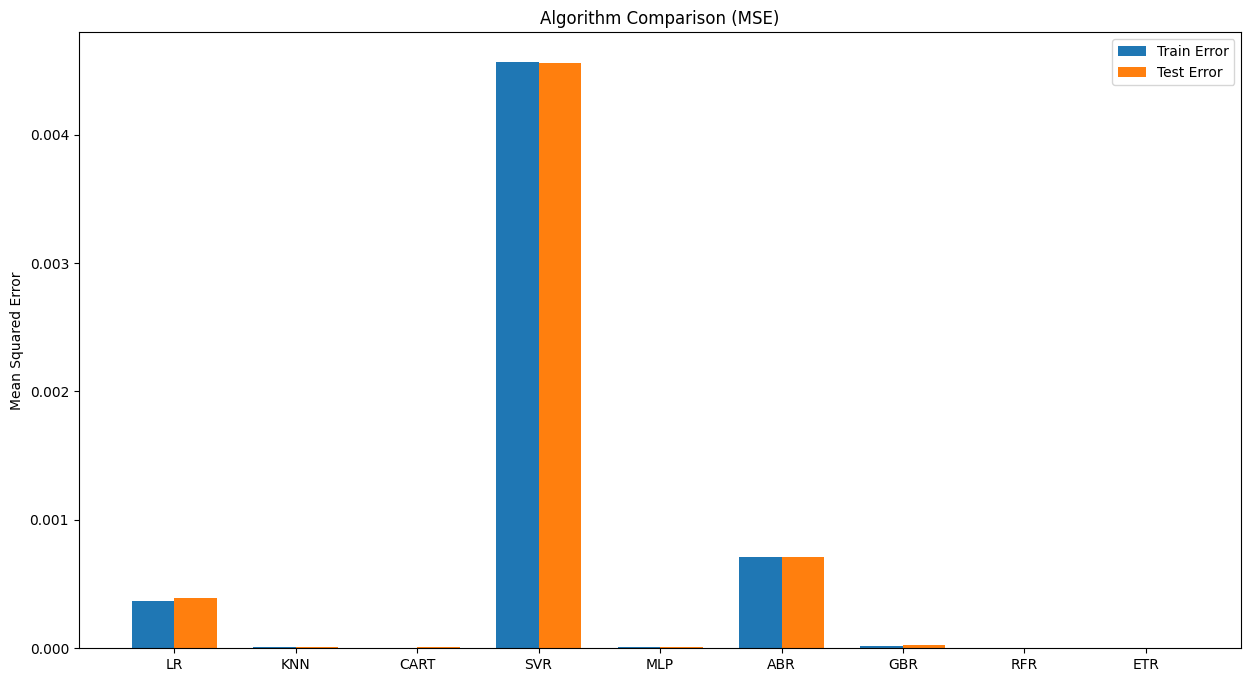

In [31]:
import matplotlib.pyplot as plt
# 1. X와 Y를 하나로 합쳐서 완벽하게 NaN/Inf 제거 (X_clean, Y_clean 재생성)
# X 혹은 Y 어디에라도 NaN이 있으면 그 행(row)을 삭제합니다.
indices_to_keep = ~np.isnan(X).any(axis=1) & ~np.isnan(Y) & np.isfinite(X).all(axis=1) & np.isfinite(Y)
X_final = X[indices_to_keep]
Y_final = Y[indices_to_keep]

# 2. 데이터를 Train/Test로 다시 분리
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_final, Y_final, test_size=0.2, random_state=42)

# 3. 모델 리스트 및 결과 저장 공간
names = [item[0] for item in models]
train_errors = []
test_errors = []

# 4. 루프 내에서 학습 및 에러 계산
for name, model in models:
    # SVR이나 MLP는 데이터 스케일에 민감하므로 NaN이 없어도 값이 너무 크면 에러가 날 수 있음
    model.fit(X_train, Y_train)
    
    train_errors.append(mean_squared_error(Y_train, model.predict(X_train)))
    test_errors.append(mean_squared_error(Y_test, model.predict(X_test)))

# 5. 그래프 출력
fig, ax = plt.subplots(figsize=(15, 8))
ind = np.arange(len(models))
width = 0.35

ax.bar(ind - width/2, train_errors, width=width, label='Train Error')
ax.bar(ind + width/2, test_errors, width=width, label='Test Error')

ax.set_title('Algorithm Comparison (MSE)')
ax.set_xticks(ind)
ax.set_xticklabels(names)
ax.set_ylabel('Mean Squared Error')
ax.legend()

plt.show()

# **모델 튜닝 및 모델 확정**

In [33]:
param_grid = {
    'hidden_layer_sizes': [
        (20,),
        (50,),
        (20, 20),
        (20, 30, 20)
    ]
}

model = MLPRegressor()

kfold = KFold(
    n_splits=num_folds,
    shuffle=True,
    random_state=seed
)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring,
    cv=kfold
)

grid_result = grid.fit(X_train, Y_train)

print(
    "Best: %f using %s"
    % (grid_result.best_score_, grid_result.best_params_)
)

means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))


Best: -0.000033 using {'hidden_layer_sizes': (20, 30, 20)}
-0.000551 (0.000384) with: {'hidden_layer_sizes': (20,)}
-0.000302 (0.000539) with: {'hidden_layer_sizes': (50,)}
-0.000126 (0.000098) with: {'hidden_layer_sizes': (20, 20)}
-0.000033 (0.000012) with: {'hidden_layer_sizes': (20, 30, 20)}


In [34]:
# 모델 준비
model_tuned = MLPRegressor(hidden_layer_sizes=(20, 30, 20))
model_tuned.fit(X_train, Y_train)

# 검증셋에 대한 정확도 추정
# 검증 데이터셋 변환
predictions = model_tuned.predict(X_test)
print(mean_squared_error(Y_test, predictions))

8.744280510016852e-05
